In [1]:
library(Seurat)
library(harmony)
library(qs)
library(ggplot2)
library(patchwork)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.0 but the current
version is 1.7.2; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

qs 0.27.2. Announcement: https://github.com/qsbase/qs/issues/103



In [2]:
seurat_obj <- readRDS("../Data/in/seurat_obj/p3f_short_induction_8_24_hrs.rds")
seurat_obj

An object of class Seurat 
20080 features across 21071 samples within 1 assay 
Active assay: RNA (20080 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [3]:
head(seurat_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,condition,log10GenesPerUMI,seurat_clusters,S.Score,G2M.Score,Phase,sample_names,Idents,Progenitor_Score1,Proliferative_Score2,Differentiated_Score3,muscle_lineage_score,RNA_snn_res.0.1,RNA_snn_res.0.2,RNA_snn_res.0.3,clusters
,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>
AAACCCAAGAGAGGGC-1_1_1_1,SeuratProject,21905,4853,3.6064825,Dbt-0-0hr,0.8492048,1,0.191262697,0.00939826,S,"0 ng/mL, 0 hrs",RNA_snn_res.0.4,0.2044684,0.2947258,-0.001803495,-0.2062719,2,2,1,cycling
AAACCCACAATGCAGG-1_1_1_1,SeuratProject,44195,7363,4.9462609,Dbt-0-0hr,0.8324530,0,-0.297385574,-0.37790713,G1,"0 ng/mL, 0 hrs",RNA_snn_res.0.4,0.3515736,-0.1356957,-0.020567355,-0.3721410,0,0,0,ground state
AAACCCACAGCGTACC-1_1_1_1,SeuratProject,15155,3763,2.6525899,Dbt-0-0hr,0.8552772,0,-0.232865139,-0.43248738,G1,"0 ng/mL, 0 hrs",RNA_snn_res.0.4,0.2560516,-0.1790518,0.030243585,-0.2258080,0,0,0,ground state
AAACGAAAGACATCCT-1_1_1_1,SeuratProject,13801,3543,2.9273241,Dbt-0-0hr,0.8573546,2,0.007865970,0.32634891,G2M,"0 ng/mL, 0 hrs",RNA_snn_res.0.4,0.1640469,0.4243307,-0.037858760,-0.2019057,1,1,2,cycling
AAACGAAAGTAGATCA-1_1_1_1,SeuratProject,26460,5252,0.8201058,Dbt-0-0hr,0.8412095,2,-0.002939748,0.57796812,G2M,"0 ng/mL, 0 hrs",RNA_snn_res.0.4,0.2882405,0.6498727,-0.029505334,-0.3177458,1,1,2,cycling
AAACGAACACTACTTT-1_1_1_1,SeuratProject,11542,3505,3.2316756,Dbt-0-0hr,0.8725856,0,-0.257425761,-0.38754698,G1,"0 ng/mL, 0 hrs",RNA_snn_res.0.4,0.3353162,-0.1316628,0.028133230,-0.3071830,0,0,0,ground state


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


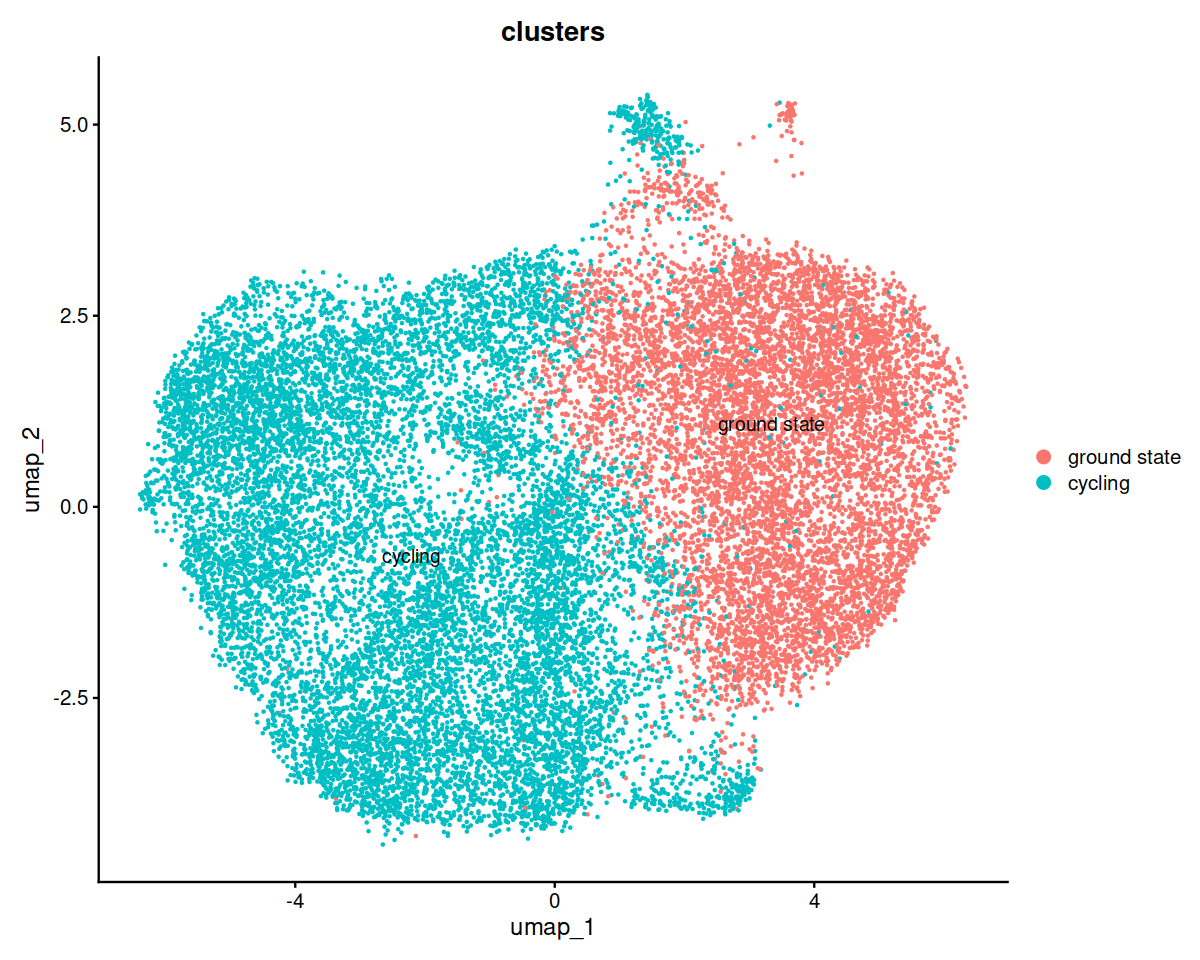

In [4]:
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(seurat_obj, group.by="clusters", label=TRUE)

In [5]:
md <- seurat_obj[[]]

qc_report <- tibble::tibble(
  total_cells = nrow(md),
  pass_nFeature_low  = mean(md$nFeature_RNA > 1000, na.rm = TRUE),
  pass_nFeature_high = mean(md$nFeature_RNA < 7500, na.rm = TRUE),
  pass_nCount_low    = mean(md$nCount_RNA > 1000, na.rm = TRUE),
  pass_nCount_high   = mean(md$nCount_RNA < 45000, na.rm = TRUE),
  pass_mt            = mean(md$percent.mt < 10, na.rm = TRUE),
  pass_all = mean(
    (md$nFeature_RNA > 1000) &
    (md$nFeature_RNA < 7500) &
    (md$nCount_RNA > 1000) &
    (md$nCount_RNA < 45000) &
    (md$percent.mt < 10),
    na.rm = TRUE
  )
)

qc_report


total_cells,pass_nFeature_low,pass_nFeature_high,pass_nCount_low,pass_nCount_high,pass_mt,pass_all
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21071,0.9916947,0.9974847,1,0.9909829,0.992027,0.9761283


In [6]:
seurat_obj <- subset(
  seurat_obj,
  subset = nFeature_RNA > 1000 &
           nFeature_RNA < 7500 &
           percent.mt < 10 &
           nCount_RNA > 1000 &
            nCount_RNA < 45000 &
            percent.mt < 10
)

seurat_obj

An object of class Seurat 
20080 features across 20568 samples within 1 assay 
Active assay: RNA (20080 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [7]:
n_feat=2000
n_pc=20

DefaultAssay(seurat_obj) <- "RNA"
seurat_split <- SplitObject(seurat_obj,split.by="condition")

combined <- merge(
        x = seurat_split[[1]],
        y = seurat_split[-1],
        add.cell.ids = names(seurat_split),
        project = "HarmonyIntegration"
)

#combined <- JoinLayers(combined)
combined <- NormalizeData(combined, verbose = FALSE)
combined <- FindVariableFeatures(combined, selection.method = "vst", nfeatures = n_feat, verbose = FALSE)
combined <- ScaleData(combined, features = VariableFeatures(combined))

combined <- RunPCA(combined, npcs = n_pc, verbose = FALSE)
combined <- RunHarmony(
        object = combined,
        group.by.vars = "condition",
        assay.use = "RNA",
        reduction.use = "pca",  
        dims.use = 1:n_pc,
        verbose = TRUE
)

combined <- FindNeighbors(combined, reduction="harmony", dims = 1:n_pc)
combined <- RunUMAP(combined, reduction = "harmony", dims = 1:n_pc)
resolutions_to_test <- c(0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5)
for (res in resolutions_to_test) {
        combined <- FindClusters(combined, resolution = res, verbose = FALSE)
}

Centering and scaling data matrix

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
14:01:18 UMAP embedding parameters a = 0.9922 b = 1.112

14:01:18 Read 20568 rows and found 20 numeric columns

14:01:18 Using Annoy for neighbor search, n_neighbors = 30

14:01:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*

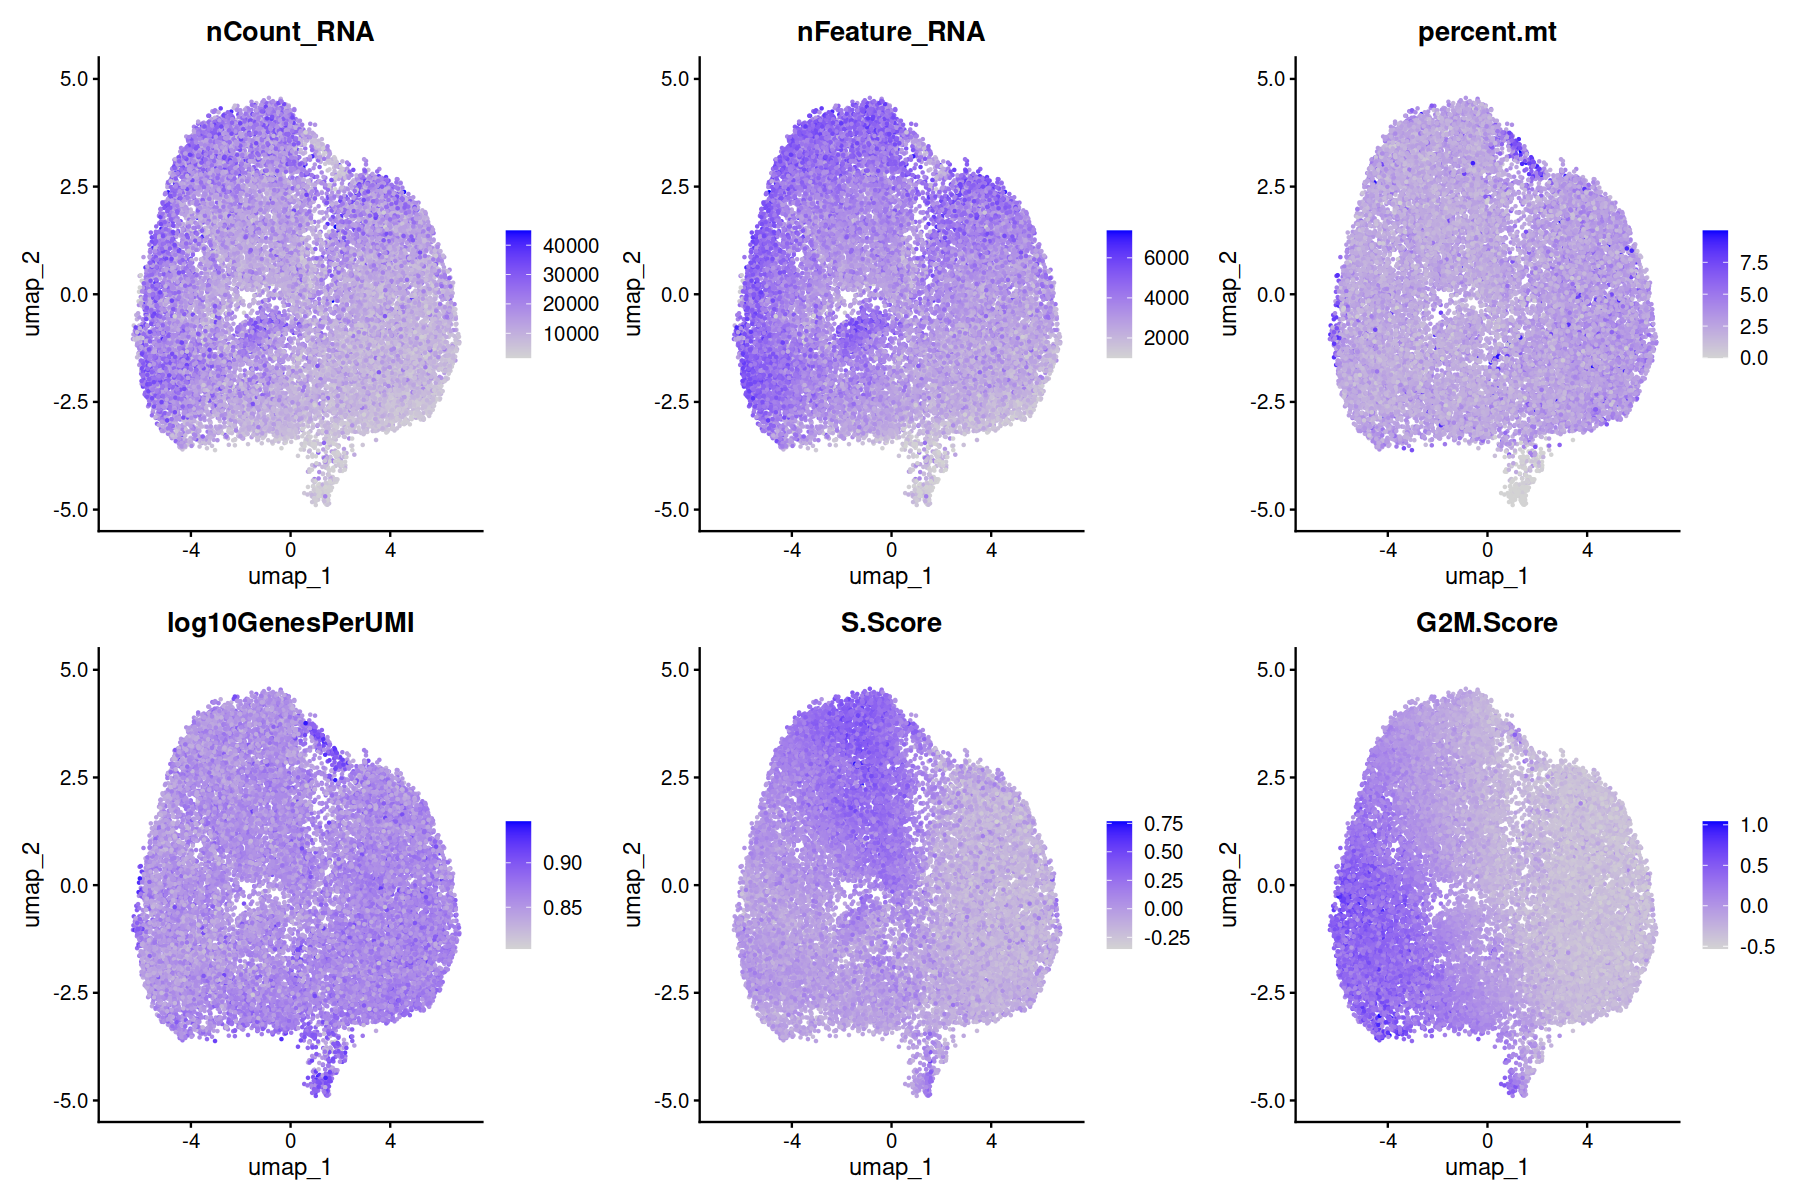

In [8]:
options(repr.plot.width = 15, repr.plot.height = 10)

num_fields <- c("nCount_RNA","nFeature_RNA","percent.mt","log10GenesPerUMI","S.Score","G2M.Score")
plot_umap_num <- function(obj, fields) {
  plots <- lapply(fields, function(f) FeaturePlot(obj, features = f) + ggtitle(f))
  wrap_plots(plots, ncol = 3)
}

p2 <- plot_umap_num(combined, num_fields)
p2

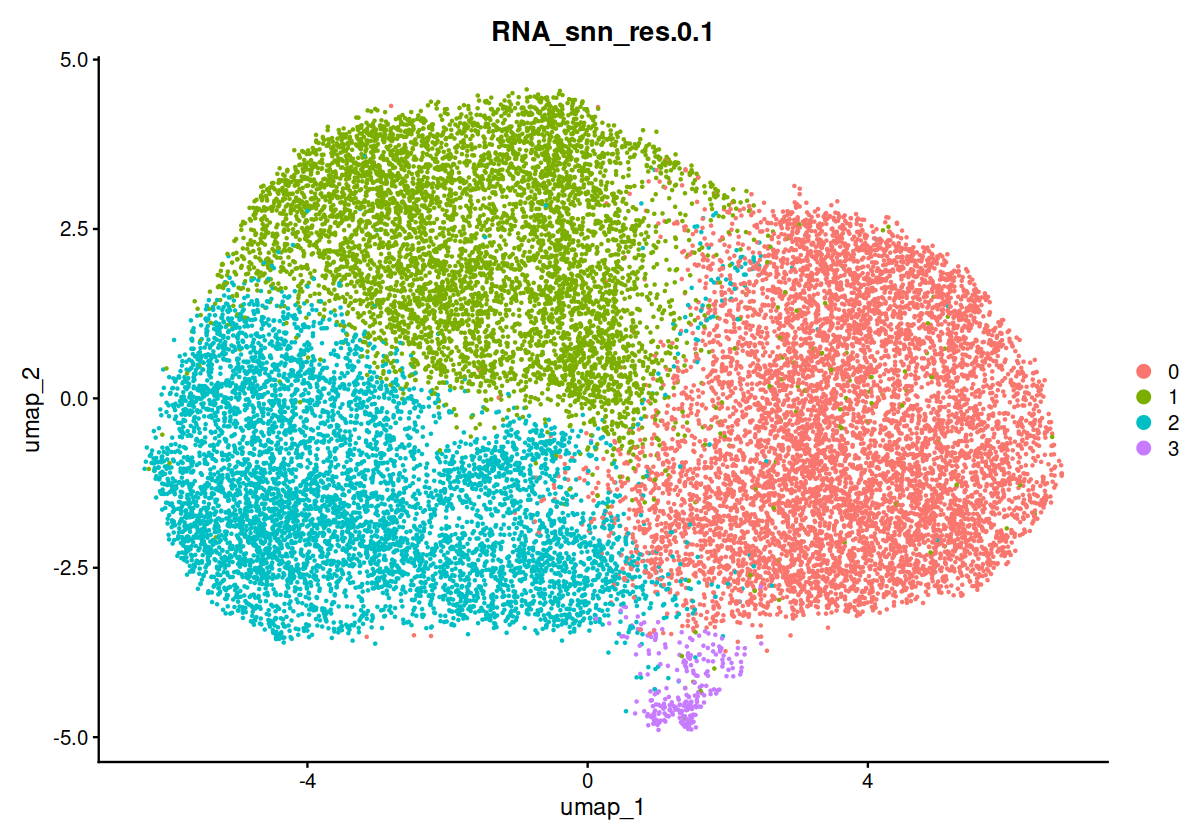

In [9]:
options(repr.plot.width=10, repr.plot.height=7)
DimPlot(combined, group.by="RNA_snn_res.0.1")

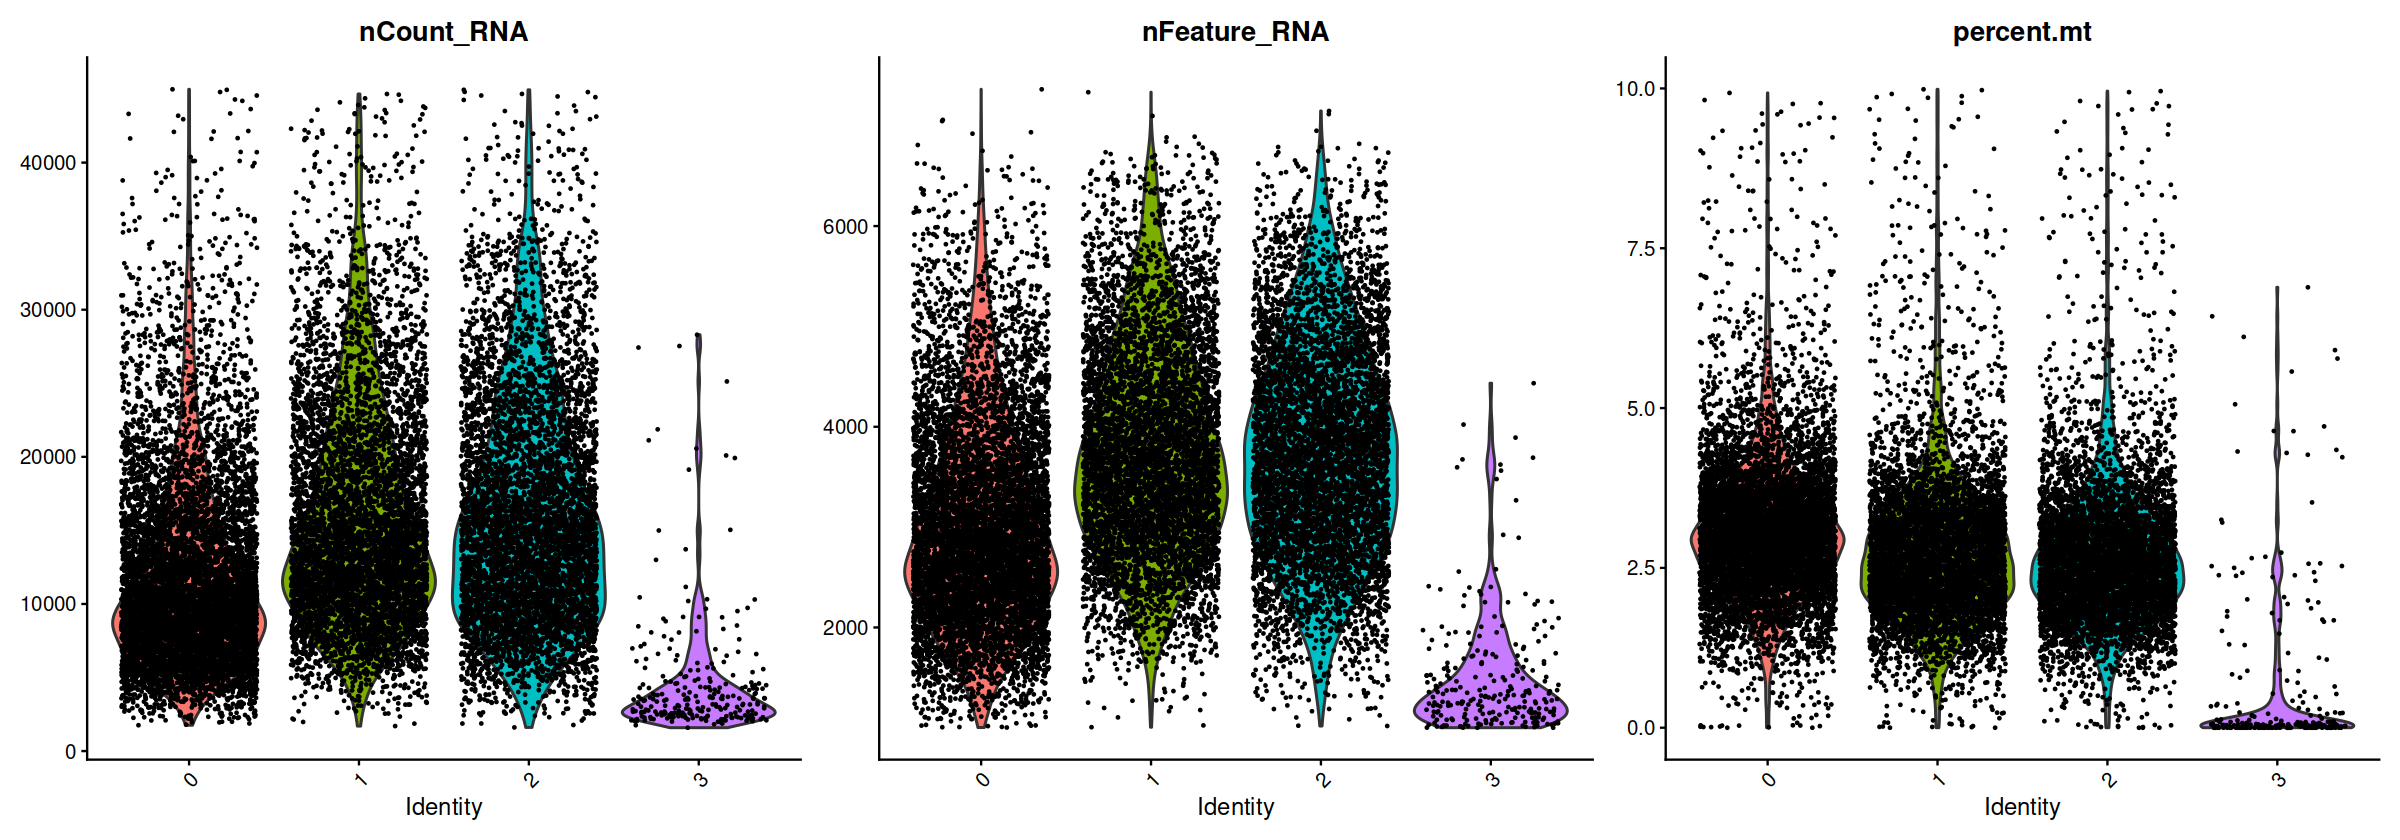

In [10]:
options(repr.plot.width=20, repr.plot.height=7)
VlnPlot(combined, c("nCount_RNA","nFeature_RNA","percent.mt"), group.by="RNA_snn_res.0.1")

In [11]:
library(openxlsx)
library(dplyr)

all.markers <- FindAllMarkers(object = combined, group.by = "RNA_snn_res.0.1")

out_file <- "./out/Markers_Phase_Precluster.xlsx"
wb <- createWorkbook()

group_col <- "cluster"
clusters <- sort(unique(as.character(all.markers[[group_col]])))

make_sheet_names <- function(x) {
  x <- gsub("[:\\\\/?*\\[\\]]", "_", x)
  x <- substr(x, 1, 31)
  x <- make.unique(x, sep = "_")
  substr(x, 1, 31)  
}

sheet_names <- make_sheet_names(clusters)

for (i in seq_along(clusters)) {
  cl <- clusters[i]
  sheet_name <- sheet_names[i]

  df <- all.markers %>%
    dplyr::filter(.data[[group_col]] == cl) %>%
    dplyr::arrange(p_val_adj, dplyr::desc(avg_log2FC), gene)

  addWorksheet(wb, sheet_name)
  writeDataTable(wb, sheet = sheet_name, x = df)
  setColWidths(wb, sheet = sheet_name, cols = 1:ncol(df), widths = "auto")
}

saveWorkbook(wb, out_file, overwrite = TRUE)
message("Saved: ", normalizePath(out_file))



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Saved: /gpfs0/home2/gdstantonlab/lab/axk201/BenLab_PAX3_FOXO1_SingleCellAnalysis/Notebook/Data/out/Markers_Phase_Precluster.xlsx



Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 13 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 100000)”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 2 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 100000)”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 1 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) 

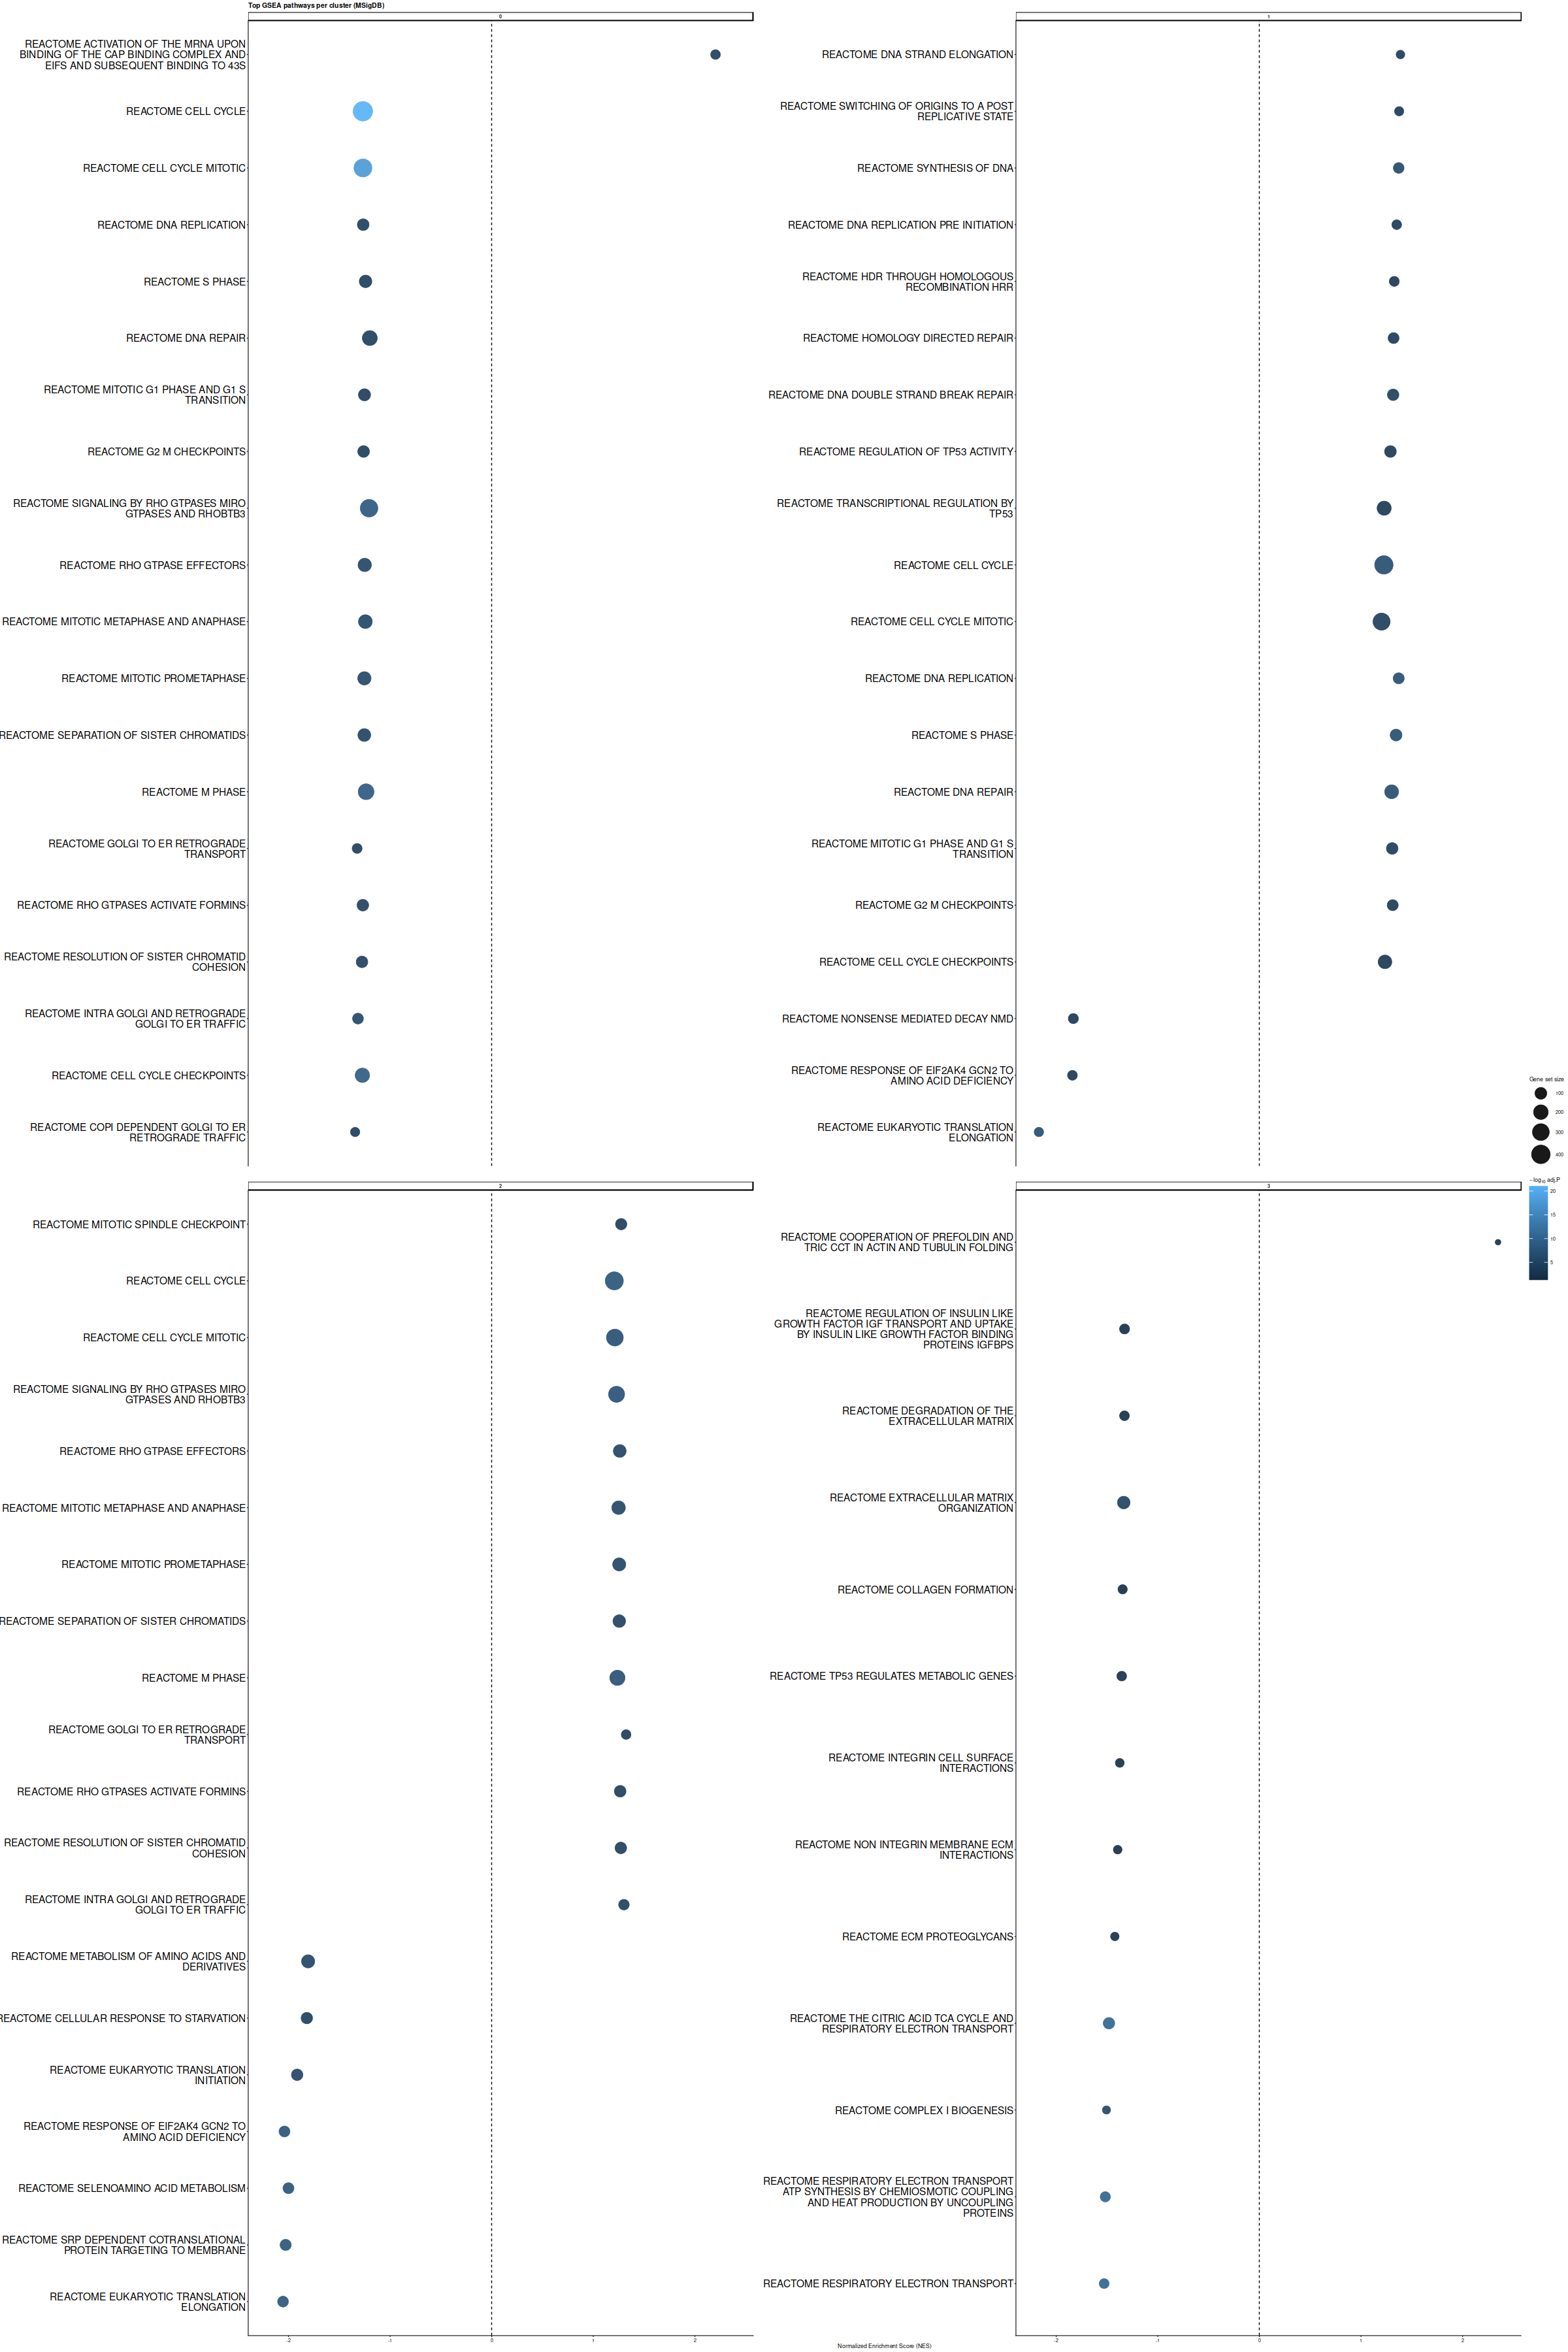

In [12]:
options(repr.plot.width=20, repr.plot.height=30)

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(forcats)
  library(ggplot2)
  library(clusterProfiler)
  library(msigdbr)
})

# -----------------------
# Params
# -----------------------
species <- "Homo sapiens"
msig_category <- "C2"         
msig_subcategory <-  "CP:REACTOME"     

top_terms_per_cluster <- 20
padj_cutoff <- 0.05

minGSSize <- 10
maxGSSize <- 500
gsea_pCutoff <- 0.05           
nPermSimple <- 10000      

m_df <- msigdbr(species = species, category = msig_category)
if (!is.null(msig_subcategory)) m_df <- m_df %>% filter(gs_subcat == msig_subcategory)
term2gene <- m_df %>% dplyr::select(gs_name, gene_symbol)

rank_lists <- all.markers %>%
  group_by(cluster, gene) %>%
  summarize(
    avg_log2FC = mean(avg_log2FC, na.rm = TRUE),
    p_val_adj  = min(p_val_adj, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC)) %>%
  group_split()

names(rank_lists) <- sapply(rank_lists, function(df) unique(df$cluster))


make_rank <- function(df) {
  score <- df$avg_log2FC * -log10(pmax(df$p_val_adj, 1e-300))
  names(score) <- df$gene
  sort(score, decreasing = TRUE)
}

# -----------------------
# Run GSEA per cluster
# -----------------------
gsea_list <- lapply(names(rank_lists), function(cl){
  df <- rank_lists[[cl]]
  geneRank <- make_rank(df)
  geneRank <- geneRank[is.finite(geneRank)]
  geneRank <- geneRank[!duplicated(names(geneRank))]

  g <- tryCatch({
    GSEA(
      geneList      = geneRank,
      TERM2GENE     = term2gene,
      pvalueCutoff  = gsea_pCutoff,
      pAdjustMethod = "BH",
      minGSSize     = minGSSize,
      maxGSSize     = maxGSSize,
      eps           = 0,             
      nPermSimple   = nPermSimple,
      verbose       = FALSE
    )
  }, error = function(e) NULL)

  if (is.null(g) || nrow(as.data.frame(g)) == 0) return(NULL)

  as.data.frame(g) %>%
    mutate(cluster = as.character(cl))
})

gsea_df <- bind_rows(gsea_list)


top_df <- gsea_df %>%
  filter(p.adjust < padj_cutoff) %>%
  #filter(NES > 0) %>%
  group_by(cluster) %>%
  arrange(p.adjust) %>%
  slice_head(n = top_terms_per_cluster) %>%
  ungroup() %>%
  mutate(
    neglog10_padj = -log10(p.adjust),
    Description = str_replace_all(Description, "_", " "),
    Description = str_wrap(Description, width = 40)
  )

p <- ggplot(top_df, aes(x = NES, y = fct_reorder(Description, NES))) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.3) +
  geom_point(aes(size = setSize, color = neglog10_padj), alpha = 0.9) +
  facet_wrap(~ cluster, scales = "free_y", ncol = 2) +
  scale_size_continuous(range = c(2, 8)) +
  labs(
    x = "Normalized Enrichment Score (NES)",
    y = NULL,
    color = expression(-log[10]~adj.P),
    size = "Gene set size",
    title = "Top GSEA pathways per cluster (MSigDB)"
  ) +
  theme_classic(base_size = 5) +
  theme(
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold"),
    axis.text.y = element_text(size = 9),
    panel.spacing = unit(1.0, "lines")
  )

p


ggsave("cluster_pathways_top10_GSEA_msigdb_induction_8_24_hrs.pdf",
       plot = p,
       width = 12, height = 18, units = "in",
       dpi = 300, useDingbats = FALSE)


In [16]:
markers <- read.csv("./in/scrna_velocity/danielli_2024_markers.csv", header = TRUE)
diff_exp <- read.csv("./in/scrna_velocity/markers_dosage_2wks.csv", header = TRUE)
markers <- as.list(markers)
markers$Progenitor_markers <- unlist(strsplit(markers$Progenitor_markers, "'"))
markers$Proliferative_markers <- unlist(strsplit(markers$Proliferative_markers, "'"))
markers$Differentiated_markers <- unlist(strsplit(markers$Differentiated_markers, "'"))
p3f_top20 <- diff_exp %>%
  filter(cluster == "PAX3-FOXO1-specific",
         !is.na(p_val_adj),
         p_val_adj <= 0.01,
         avg_log2FC >= 1.0) %>%
  arrange(desc(avg_log2FC), p_val_adj, desc(pct.1 - pct.2)) %>%
  distinct(gene, .keep_all = TRUE) %>%   
  slice_head(n = 200)

markers[['PAX3-FOXO1-Specific']] <- p3f_top20$gene

cycling_top20 <- diff_exp %>%
  filter(cluster == "Cycling",
         !is.na(p_val_adj),
         p_val_adj <= 0.01,
         avg_log2FC >= 1.0) %>%
  arrange(desc(avg_log2FC), p_val_adj, desc(pct.1 - pct.2)) %>%
  distinct(gene, .keep_all = TRUE) %>%   
  slice_head(n = 200)

markers$Cycling <- cycling_top20$gene

ap1_top20 <- diff_exp %>%
  filter(cluster == "AP-1 expressing",
         !is.na(p_val_adj),
         p_val_adj <= 0.01,
         avg_log2FC >= 1.0) %>%
  arrange(desc(avg_log2FC), p_val_adj, desc(pct.1 - pct.2)) %>%
  distinct(gene, .keep_all = TRUE) %>%   
  slice_head(n = 200)

markers[['AP-1 expressing']] <- ap1_top20$gene


In [17]:
options(repr.plot.width=10, repr.plot.height=6)

marker_order <- names(markers)
all_markers <- rev(unique(unname(unlist(markers[marker_order]))))
all_markers <- factor(all_markers, levels = all_markers)

existing_markers <- all_markers[all_markers %in% rownames(combined)]

combined <- AddModuleScore(
  object   = combined,
  features = markers,
  name     = "Module"             
)

old_cols <- setdiff(colnames(combined@meta.data), paste0("Module", 1:1000))  
all_new  <- grep("^Module", colnames(combined@meta.data), value = TRUE)

N <- length(markers)
score_cols <- setdiff(all_new, grep("CTRL", all_new, value = TRUE))[seq_len(N)]

names(score_cols) <- names(markers)
colnames(combined@meta.data)[match(score_cols, colnames(combined@meta.data))] <-
  paste0(names(markers), "_Score")

score_cols <- paste0(names(markers), "_Score")

for (nm in score_cols) {
  combined@meta.data[[paste0(nm, "_z")]] <- as.numeric(scale(combined@meta.data[[nm]]))
}
score_cols_z <- paste0(score_cols, "_z")

Warning message:
“The following features are not present in the object: POSTN, COL11A1, SCN7A, FAM129A, MEOX2, PPAP2B, TSHZ2, EDNRA, EPHA3, MMP16, MIR4435-1HG, CTGF, SFRP2, TNMD, SELM, PTGS2, NOV, NEFM, SPARCL1, CCL2, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: NNAT, CASC5, SGOL1, SGOL2, KIAA0101, FAM64A, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: COBL, 38231, CTD-2545M3.8, LRRN1, SEPW1, RGR, RP1-302G2.5, FAM178A, FAM65B, RP11-1L12.3, TRDN, RP11-14N7.2, AC007970.1, CTNNA3, TP63, SEMA6A, not searching for symbol synonyms”


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


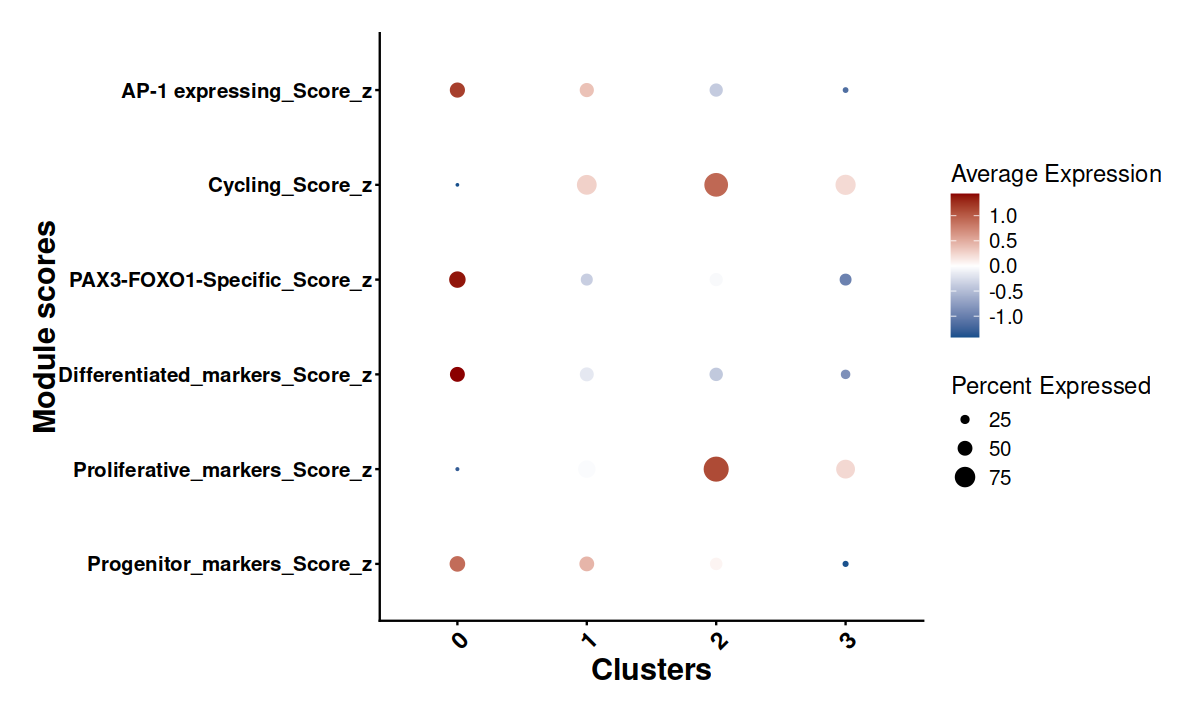

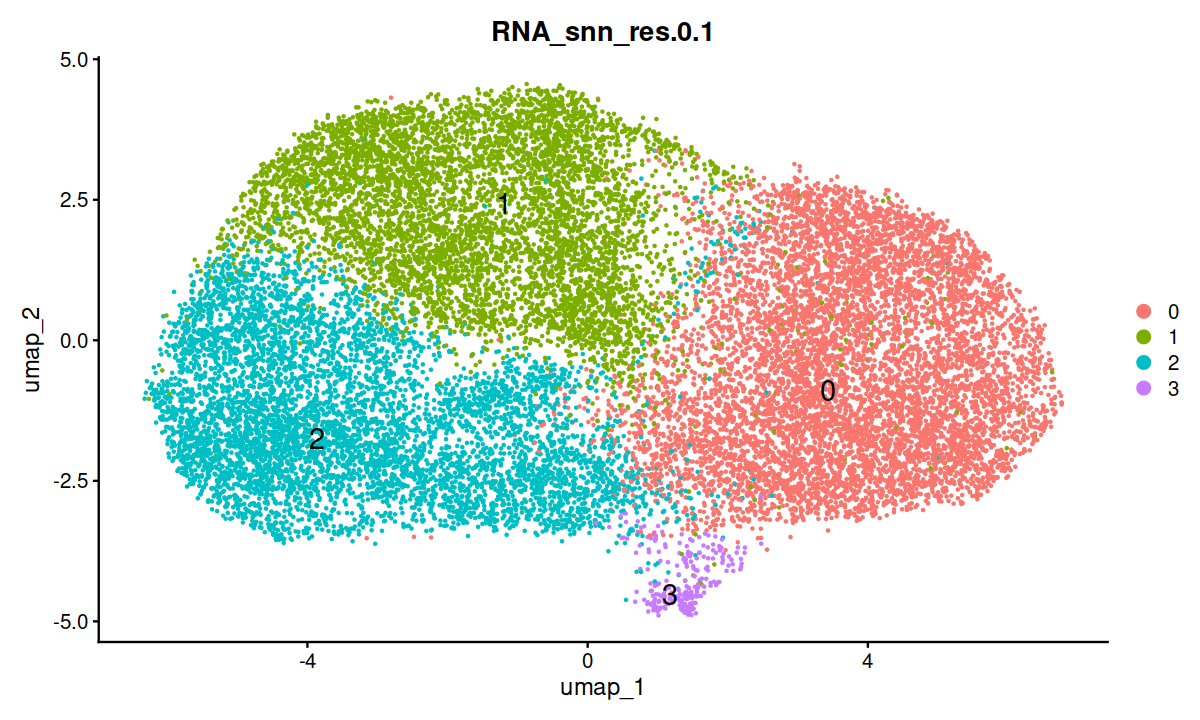

In [36]:
options(repr.plot.width=10)

p_mod <- DotPlot(
  combined,
  features = score_cols_z,
  group.by = "RNA_snn_res.0.1",
  cols = c("dodgerblue4", "white", "darkred")
) +
  scale_colour_gradient2(low = "dodgerblue4", mid = "white", high = "darkred") +
  theme_classic() + labs(y = "Clusters", x = "Module scores") +
  theme(
    plot.margin  = margin(20, 20, 20, 20, "pt"),
    axis.title.y = element_text(face = "bold", size = 18),
    axis.text.y  = element_text(face = "bold", size = 12),
    axis.title.x = element_text(face = "bold", size = 18),
    axis.text.x  = element_text(face = "bold", size = 14, angle = 45),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14)
  ) +
  RotatedAxis() + coord_flip()


p_mod

p_umap <- DimPlot(combined, group.by="RNA_snn_res.0.1", label=TRUE, label.size = 6, repel = TRUE)
p_umap

### Notes
- Top cluster 0 upregulated genes are ribosomal
- proliferation support/growth maintenance

In [37]:
cluster_annotation <- c(
    '0' = 'Ground-state',
    '1' = 'Cycling',
    '2' = 'Cycling',
    '3' = 'Cycling'
)

Idents(combined) <- "RNA_snn_res.0.1"
combined <- RenameIdents(combined, cluster_annotation)
combined$cell_label <- Idents(combined)

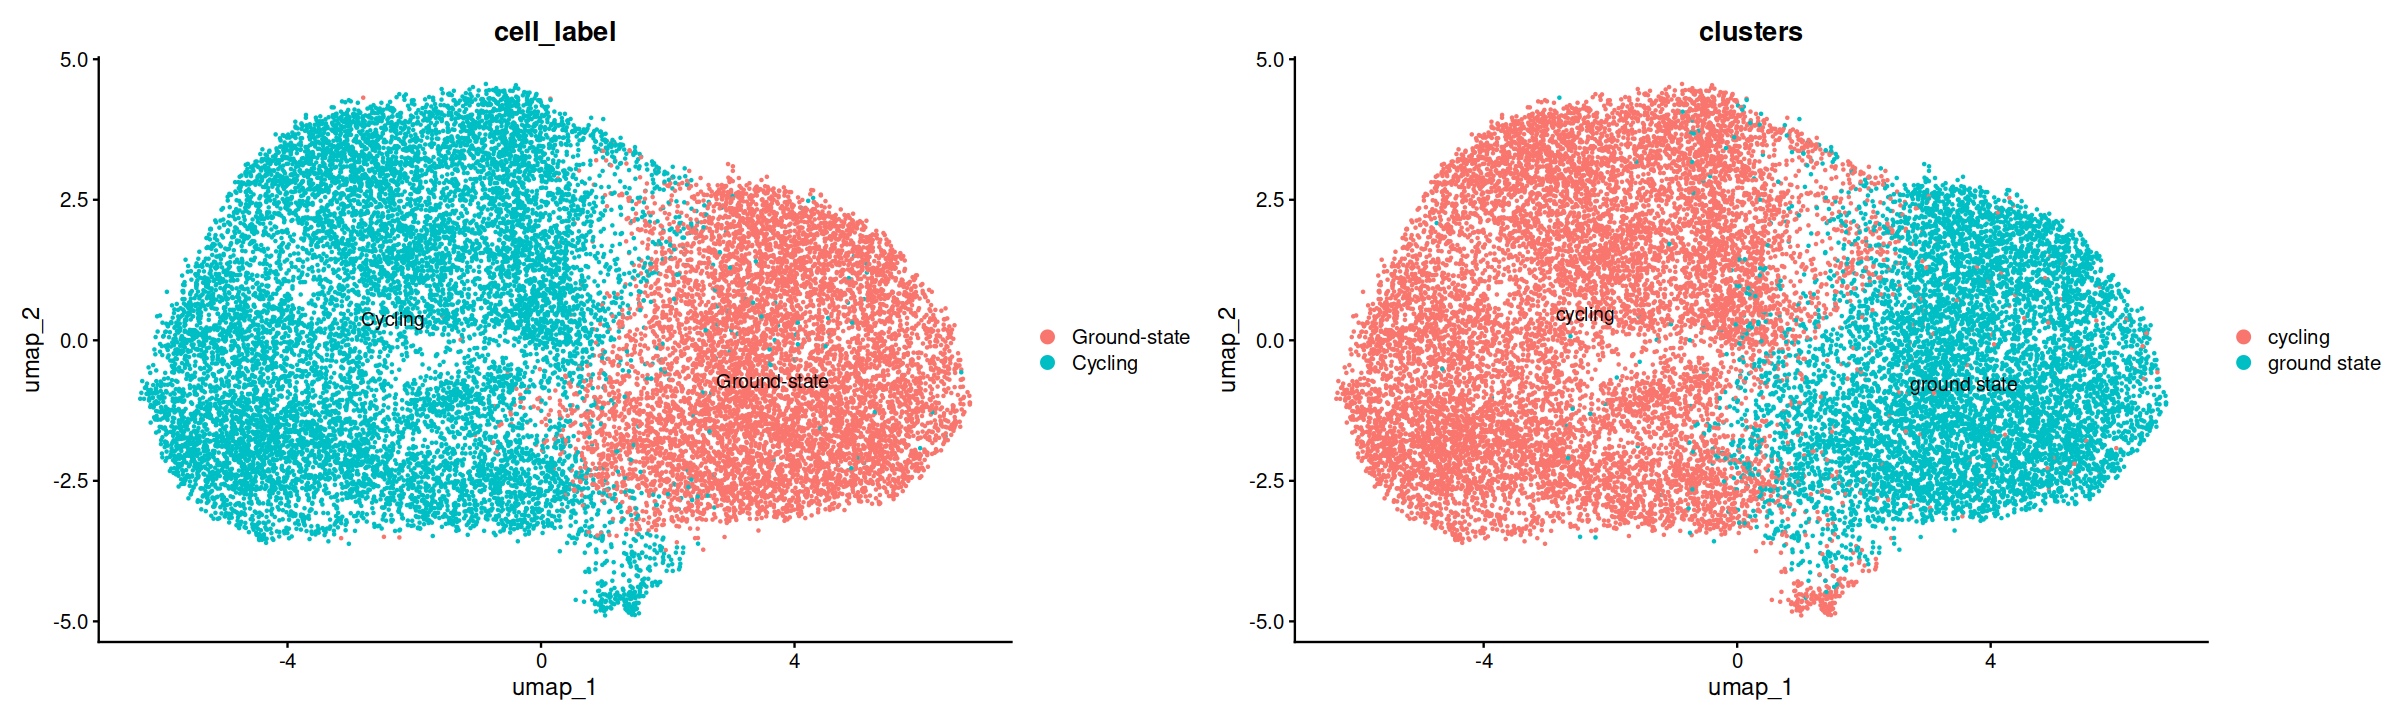

In [38]:
options(repr.plot.width=20)
DimPlot(combined, label = TRUE, group.by="cell_label") | DimPlot(combined, label = TRUE, group.by="clusters")

In [39]:
qsave(combined, file = "./out/seurat_induction_8_24_hrs_annotated.qs")

In [40]:
combined

An object of class Seurat 
20080 features across 20568 samples within 1 assay 
Active assay: RNA (20080 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [41]:
all.markers <- FindAllMarkers(object = combined, group.by="cell_label")
library(openxlsx)
out_file <- "./out/Markers_induction_8_24_hrs.xlsx"
wb <- createWorkbook()

group_col <- "cluster"

clusters <- sort(unique(as.character(all.markers[[group_col]])))

make_sheet_names <- function(x) {
  x <- gsub("[:\\\\/?*\\[\\]]", "_", x)
  x <- substr(x, 1, 31)
  make.unique(x, sep = "_")
}

sheet_names <- make_sheet_names(clusters)

for (i in seq_along(clusters)) {
  cl <- clusters[i]
  sheet_name <- sheet_names[i]

  df <- all.markers %>%
    filter(.data[[group_col]] == cl) %>%
    arrange(p_val_adj, desc(avg_log2FC), gene)

  addWorksheet(wb, sheet_name)
  writeDataTable(wb, sheet = sheet_name, x = df)
  setColWidths(wb, sheet = sheet_name, cols = 1:ncol(df), widths = "auto")
}

saveWorkbook(wb, out_file, overwrite = TRUE)
message("Saved: ", normalizePath(out_file))

Calculating cluster Ground-state

Calculating cluster Cycling

Saved: /gpfs0/home2/gdstantonlab/lab/axk201/BenLab_PAX3_FOXO1_SingleCellAnalysis/Notebook/Data/out/Markers_induction_8_24_hrs.xlsx

